In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import count
from numpy.random import default_rng

from node_b import NodeB
from slice_l1 import SliceL1eMBB, SliceL1mMTC, SliceL1URLLC
from slice_ran import SliceRANeMBB, SliceRANmMTC, SliceRANURLC
from channel_models import SINRSelectiveFading, MCSCodeset
from anothermultiwrapper import MultiGNBWrapper

# Make sure this exists in your project
from schedulers import ProportionalFair

In [2]:
rng = default_rng(42)

slots_per_step = 50
slot_length = 1e-3
n_prbs = 100

# -------------------- eMBB --------------------
CBR_description = {
    'lambda': 2.0 / 60.0,
    't_mean': 30.0,
    'bit_rate': 500000
}

VBR_description = {
    'lambda': 5.0 / 60.0,
    't_mean': 30.0,
    'p_size': 1000,
    'b_size': 500,
    'b_rate': 1
}

SLA_embb = {
    'cbr_th': 10e6,
    'cbr_prb': 20,
    'cbr_queue': 10e4,
    'vbr_th': 15e6,
    'vbr_prb': 30,
    'vbr_queue': 15e4,
}

state_variables_embb = [
    'cbr_traffic', 'cbr_th', 'cbr_prb', 'cbr_queue', 'cbr_snr',
    'vbr_traffic', 'vbr_th', 'vbr_prb', 'vbr_queue', 'vbr_snr'
]

time_per_step = slots_per_step * slot_length

norm_const_embb = {
    'cbr_traffic': 5e6 * time_per_step,
    'cbr_th': 10e6 * time_per_step,
    'cbr_prb': 25 * slots_per_step,
    'cbr_queue': 10e4 * slots_per_step,
    'cbr_snr': 35 * slots_per_step,
    'vbr_traffic': 5e6 * time_per_step,
    'vbr_th': 10e6 * time_per_step,
    'vbr_prb': 35 * slots_per_step,
    'vbr_queue': 10e4 * slots_per_step,
    'vbr_snr': 35 * slots_per_step,
}

# -------------------- mMTC --------------------
MTC_description = {
    'n_devices': 1000,
    'repetition_set': [2, 4, 8, 16, 32, 64, 128],
    'period_set': [1000, 50000, 10000, 15000, 20000, 25000, 50000, 100000]
}

SLA_mmtc = {'delay': 300}
state_variables_mmtc = ['devices', 'avg_rep', 'delay']

norm_const_mmtc = {
    'devices': 100 * slots_per_step,
    'avg_rep': 100 * slots_per_step,
    'delay': 100 * slots_per_step
}

# -------------------- URLLC --------------------
URLLC_CBR_description = {
    'lambda': 2.0 / 60.0,
    't_mean': 30.0,
    'bit_rate': 500000
}

URLLC_VBR_description = {
    'lambda': 5.0 / 60.0,
    't_mean': 30.0,
    'p_size': 1000,
    'b_size': 500,
    'b_rate': 1
}

SLA_urllc = {
    'cbr_th': 10e6,
    'cbr_prb': 20,
    'cbr_queue': 5e4,
    'vbr_th': 15e6,
    'vbr_prb': 30,
    'vbr_queue': 10e4,
}

state_variables_urllc = [
    'cbr_traffic', 'cbr_th', 'cbr_prb', 'cbr_queue', 'cbr_snr',
    'vbr_traffic', 'vbr_th', 'vbr_prb', 'vbr_queue', 'vbr_snr'
]

norm_const_urllc = {
    'cbr_traffic': 2e6 * time_per_step,
    'cbr_th': 5e6 * time_per_step,
    'cbr_prb': 15 * slots_per_step,
    'cbr_queue': 5e3 * slots_per_step,
    'cbr_snr': 35 * slots_per_step,
    'vbr_traffic': 2e6 * time_per_step,
    'vbr_th': 7e6 * time_per_step,
    'vbr_prb': 20 * slots_per_step,
    'vbr_queue': 5e3 * slots_per_step,
    'vbr_snr': 35 * slots_per_step,
}

In [3]:
def build_gnb(
    rng,
    gnb_id,
    x,
    y,
    n_prbs=100,
    coverage_radius=300,
    n_embb=1,
    n_mmtc=1,
    n_urllc=0,
    slots_per_step=50,
    slot_length=1e-3,
    propagation_type='macro_cell_urban_2GHz'
):
    snr_generator = SINRSelectiveFading(rng, propagation_type, n_prbs=n_prbs)
    mcs_codeset = MCSCodeset()
    scheduler = ProportionalFair(mcs_codeset)
    user_counter = count(gnb_id * 100000)  # avoid ID collisions across gNBs

    slices_l1 = []

    # eMBB slices
    for sid in range(n_embb):
        slice_ran_embb = SliceRANeMBB(
            rng, user_counter, sid,
            SLA_embb, CBR_description, VBR_description,
            state_variables_embb, norm_const_embb,
            slots_per_step, slot_length=slot_length
        )
        slice_l1_embb = SliceL1eMBB(
            rng, snr_generator,
            max(1, n_prbs // max(1, (n_embb + n_mmtc + n_urllc))),
            [slice_ran_embb],
            scheduler
        )
        slices_l1.append(slice_l1_embb)

    # mMTC slices
    for sid in range(n_mmtc):
        slice_ran_mmtc = SliceRANmMTC(
            rng, sid, SLA_mmtc, MTC_description,
            state_variables_mmtc, norm_const_mmtc, slots_per_step
        )
        slice_l1_mmtc = SliceL1mMTC(
            max(1, n_prbs // max(1, (n_embb + n_mmtc + n_urllc))),
            [slice_ran_mmtc]
        )
        slices_l1.append(slice_l1_mmtc)

    # URLLC slices
    for sid in range(n_urllc):
        slice_ran_urllc = SliceRANURLC(
            rng, user_counter, sid,
            SLA_urllc, URLLC_CBR_description, URLLC_VBR_description,
            state_variables_urllc, norm_const_urllc,
            slots_per_step, slot_length=slot_length
        )
        slice_l1_urllc = SliceL1URLLC(
            rng, snr_generator,
            max(1, n_prbs // max(1, (n_embb + n_mmtc + n_urllc))),
            [slice_ran_urllc],
            scheduler
        )
        slices_l1.append(slice_l1_urllc)

    gnb = NodeB(
        id=gnb_id,
        x=x,
        y=y,
        slices_l1=slices_l1,
        slots_per_step=slots_per_step,
        n_prbs=n_prbs,
        coverage_radius=coverage_radius,
        slot_length=slot_length
    )
    return gnb

In [4]:
gnb1 = build_gnb(
    rng=rng,
    gnb_id=0,
    x=100.0,
    y=100.0,
    n_prbs=100,
    coverage_radius=300,
    n_embb=1,
    n_mmtc=1,
    n_urllc=0,
    slots_per_step=slots_per_step
)

gnb2 = build_gnb(
    rng=rng,
    gnb_id=1,
    x=450.0,
    y=180.0,
    n_prbs=100,
    coverage_radius=300,
    n_embb=1,
    n_mmtc=0,
    n_urllc=1,
    slots_per_step=slots_per_step
)

print(gnb1)
print(gnb2)
print("gNB1 state dim:", len(gnb1.get_state()))
print("gNB2 state dim:", len(gnb2.get_state()))

NodeB 0 at (100.00, 100.00), radius=300, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 1 at (450.00, 180.00), radius=300, carrier_id=0, f=3.50GHz, bw=20.0MHz
gNB1 state dim: 15
gNB2 state dim: 22


In [5]:
env = MultiGNBWrapper(
    gnb_list=[gnb1, gnb2],
    handover_hysteresis=0.03,
    handover_ttt=2,
    outage_penalty=1.0,
    handover_penalty=0.05,
    verbose=True
)

obs, info = env.reset()
print("Observation shape:", obs.shape)
print("Initial info:", info)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

Observation shape: (43,)
Initial info: {'step': 0, 'n_gnbs': 2, 'n_tracked_ues': 0, 'n_connected_ues': 0, 'n_disconnected_ues': 0, 'ue_per_gnb': [0, 0], 'handover_count_total': 0, 'handover_count_step': 0, 'per_gnb_rewards': [0.0, 0.0], 'interference_model': 'same_carrier => interference, different_carrier => no_interference'}
Action space: Box(0.0, 1.0, (4,), float32)
Observation space: Box(-inf, inf, (43,), float32)


In [6]:
ue_ids = []
ue_ids.append(env.add_ue(x=50,  y=120, vx=8.0,  vy=0.0, slice_type="eMBB"))
ue_ids.append(env.add_ue(x=180, y=90,  vx=4.0,  vy=1.0, slice_type="eMBB"))
ue_ids.append(env.add_ue(x=320, y=160, vx=3.0,  vy=0.0, slice_type="URLLC"))
ue_ids.append(env.add_ue(x=600, y=250, vx=-5.0, vy=-1.0, slice_type="mMTC"))

print("Tracked UE IDs:", ue_ids)
print(env.get_all_ues())

[UE added] ue_id=0, pos=(50.00,120.00), vel=(8.00,0.00), serving_gnb=0
[UE added] ue_id=1, pos=(180.00,90.00), vel=(4.00,1.00), serving_gnb=0
[UE added] ue_id=2, pos=(320.00,160.00), vel=(3.00,0.00), serving_gnb=1
[UE added] ue_id=3, pos=(600.00,250.00), vel=(-5.00,-1.00), serving_gnb=1
Tracked UE IDs: [0, 1, 2, 3]
{0: {'id': 0, 'x': 50.0, 'y': 120.0, 'vx': 8.0, 'vy': 0.0, 'slice_type': 'eMBB', 'serving_gnb': 0, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0}, 1: {'id': 1, 'x': 180.0, 'y': 90.0, 'vx': 4.0, 'vy': 1.0, 'slice_type': 'eMBB', 'serving_gnb': 0, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0}, 2: {'id': 2, 'x': 320.0, 'y': 160.0, 'vx': 3.0, 'vy': 0.0, 'slice_type': 'URLLC', 'serving_gnb': 1, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0}, 3: {'id': 3, 'x': 600.0, 'y': 250.0, 'vx': -5.0, 'vy': -1.0, 'slice_type': 'mMTC', 'serving_gnb': 1, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0}}


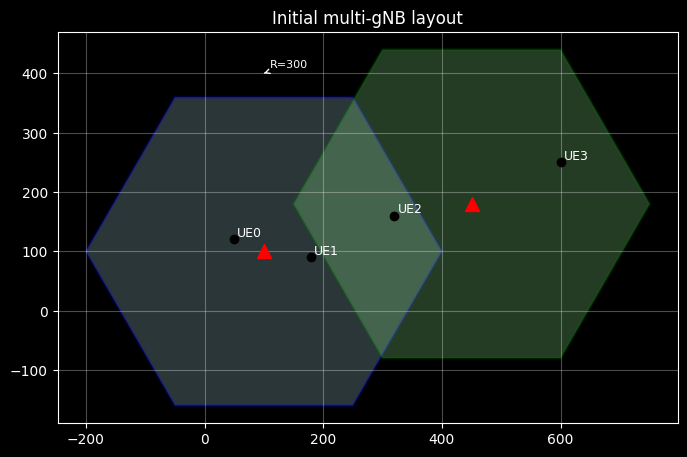

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

gnb1.visualize_coverage(ax=ax, color='lightblue', alpha=0.25, edge_color='blue')
gnb2.visualize_coverage(ax=ax, color='lightgreen', alpha=0.25, edge_color='green')

for ue_id, ue in env.get_all_ues().items():
    ax.plot(ue["x"], ue["y"], 'ko')
    ax.text(ue["x"] + 5, ue["y"] + 5, f'UE{ue_id}', fontsize=9)

ax.set_title("Initial multi-gNB layout")
ax.grid(True, alpha=0.3)
plt.show()

In [8]:
n_steps = 30

reward_history = []
handover_history = []
connected_history = []
disconnected_history = []

for t in range(n_steps):
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    reward_history.append(reward)
    handover_history.append(info["handover_count_total"])
    connected_history.append(info["n_connected_ues"])
    disconnected_history.append(info["n_disconnected_ues"])

    print(
        f"t={t:02d} | reward={reward:.3f} | "
        f"connected={info['n_connected_ues']} | "
        f"disconnected={info['n_disconnected_ues']} | "
        f"handover_total={info['handover_count_total']}"
    )

    if terminated or truncated:
        break

t=00 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=01 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=02 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=03 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=04 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=05 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=06 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=07 | reward=1.000 | connected=4 | disconnected=0 | handover_total=0
t=08 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=09 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=10 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=11 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=12 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=13 | reward=0.500 | connected=4 | disconnected=0 | handover_total=0
t=14 | reward=0.500 

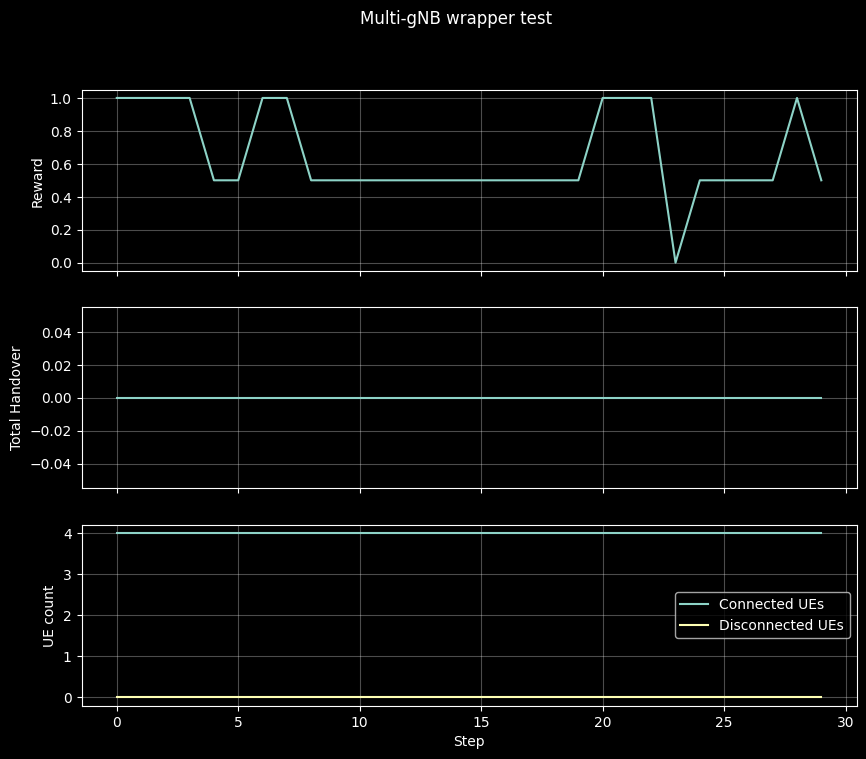

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(reward_history)
axes[0].set_ylabel("Reward")
axes[0].grid(True, alpha=0.3)

axes[1].plot(handover_history)
axes[1].set_ylabel("Total Handover")
axes[1].grid(True, alpha=0.3)

axes[2].plot(connected_history, label="Connected UEs")
axes[2].plot(disconnected_history, label="Disconnected UEs")
axes[2].set_ylabel("UE count")
axes[2].set_xlabel("Step")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Multi-gNB wrapper test")
plt.show()

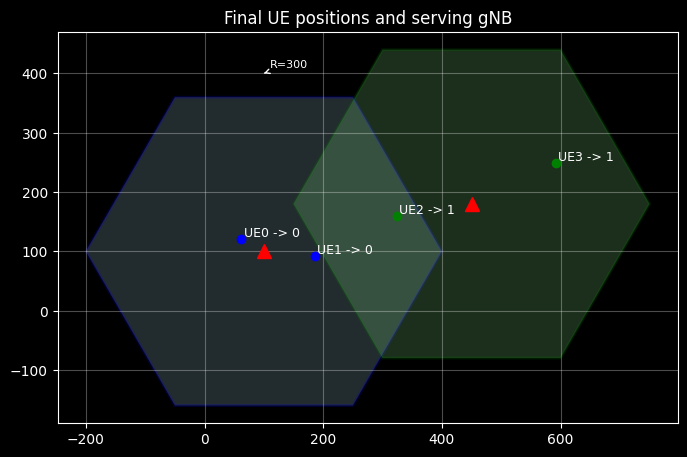

Handover log:


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

gnb1.visualize_coverage(ax=ax, color='lightblue', alpha=0.2, edge_color='blue')
gnb2.visualize_coverage(ax=ax, color='lightgreen', alpha=0.2, edge_color='green')

colors = ['blue', 'green', 'red', 'purple', 'orange']

for ue_id, ue in env.get_all_ues().items():
    serving = ue["serving_gnb"]
    c = colors[serving] if serving is not None and serving < len(colors) else 'black'
    ax.plot(ue["x"], ue["y"], 'o', color=c)
    ax.text(
        ue["x"] + 4,
        ue["y"] + 4,
        f'UE{ue_id} -> {serving}',
        fontsize=9
    )

ax.set_title("Final UE positions and serving gNB")
ax.grid(True, alpha=0.3)
plt.show()

print("Handover log:")
for event in env.handover_log:
    print(event)

In [11]:
def patched_nodeb_step(self, action):
    self.reset_info()

    if action is None or len(action) != len(self.slices_l1):
        print('The action must contain as many elements as slices!')
        return self.get_state(), self.get_info()

    if np.sum(action) > self.n_prbs:
        print('Warning: action PRBs exceed total n_prbs')

    i_prb = 0
    for slice_l1, prbs in zip(self.slices_l1, action):
        slice_l1.set_prbs(i_prb, int(prbs))
        i_prb += int(prbs)

    for _ in range(self.slots_per_step):
        self.slot()

    state = self.get_state()
    SLA_labels, violations = self.compute_reward()
    info = self.get_info(SLA_labels=SLA_labels, violations=violations)

    self.steps += 1
    return state, info

NodeB.step = patched_nodeb_step
print("NodeB.step patched for notebook testing.")

NodeB.step patched for notebook testing.


test 10 gnodeb

Created 10 gNodeBs
Observation shape: (189,)
Initial info: {'step': 0, 'n_gnbs': 10, 'n_tracked_ues': 0, 'n_connected_ues': 0, 'n_disconnected_ues': 0, 'ue_per_gnb': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'handover_count_total': 0, 'handover_count_step': 0, 'per_gnb_rewards': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'interference_model': 'same_carrier => interference, different_carrier => no_interference'}
Action dim: 19
Tracked UEs: 30
step=00 | reward=1.000 | connected=30 | disconnected=0 | handover_total=0
step=01 | reward=1.000 | connected=30 | disconnected=0 | handover_total=0
step=02 | reward=0.933 | connected=30 | disconnected=0 | handover_total=0
step=03 | reward=1.000 | connected=30 | disconnected=0 | handover_total=0
step=04 | reward=1.000 | connected=30 | disconnected=0 | handover_total=0
step=05 | reward=0.900 | connected=30 | disconnected=0 | handover_total=0
step=06 | reward=1.000 | connected=30 | disconnected=0 | handover_total=0
step=07 | reward=0.833 | connected=30

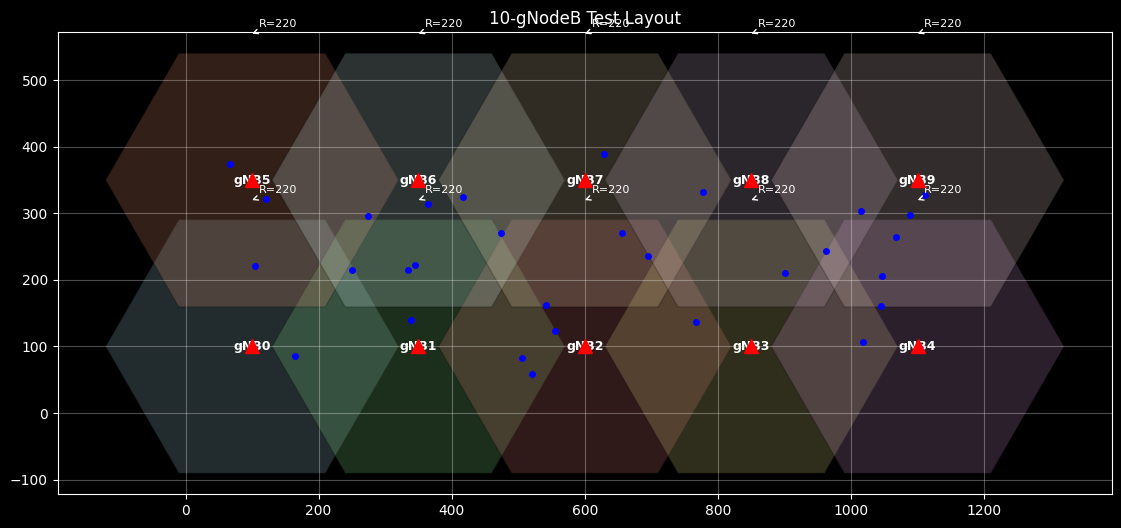

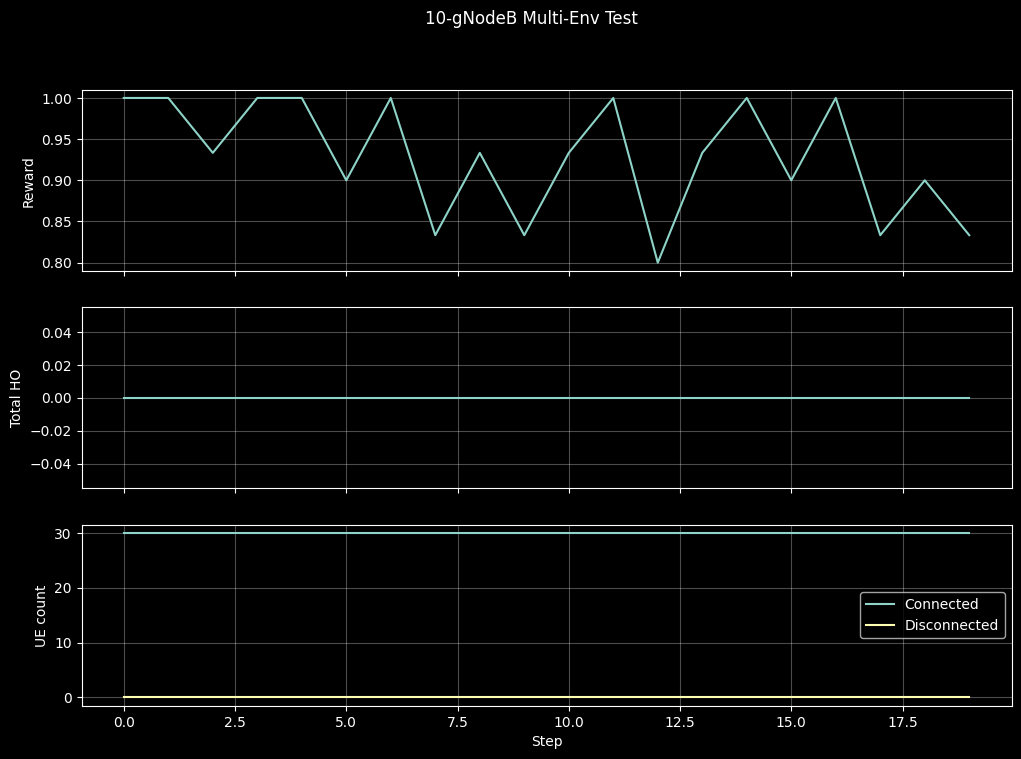

In [12]:
# =========================
# Create and test 10 gNodeBs
# =========================

rng = default_rng(123)

# Build 10 gNodeBs on a 2x5 grid
gnb_list = []
positions = [
    (100, 100), (350, 100), (600, 100), (850, 100), (1100, 100),
    (100, 350), (350, 350), (600, 350), (850, 350), (1100, 350),
]

for i, (x, y) in enumerate(positions):
    # You can vary slice composition if you want
    n_embb = 1
    n_mmtc = 1 if i % 2 == 0 else 0
    n_urllc = 1 if i % 3 == 0 else 0

    gnb = build_gnb(
        rng=rng,
        gnb_id=i,
        x=float(x),
        y=float(y),
        n_prbs=100,
        coverage_radius=220,   # tune this for more/less overlap
        n_embb=n_embb,
        n_mmtc=n_mmtc,
        n_urllc=n_urllc,
        slots_per_step=slots_per_step
    )
    gnb_list.append(gnb)

print(f"Created {len(gnb_list)} gNodeBs")

# Create wrapper
env = MultiGNBWrapper(
    gnb_list=gnb_list,
    handover_hysteresis=0.03,
    handover_ttt=2,
    outage_penalty=1.0,
    handover_penalty=0.05,
    verbose=False
)

obs, info = env.reset()
print("Observation shape:", obs.shape)
print("Initial info:", info)
print("Action dim:", env.action_space.shape[0])

# Add tracked mobile UEs
n_test_ues = 30
for k in range(n_test_ues):
    x = rng.uniform(50, 1150)
    y = rng.uniform(50, 400)
    vx = rng.uniform(-10, 10)
    vy = rng.uniform(-5, 5)
    env.add_ue(x=x, y=y, vx=vx, vy=vy, slice_type="eMBB")

print("Tracked UEs:", len(env.get_all_ues()))

# Run simulation
n_steps = 20
reward_history = []
handover_history = []
connected_history = []
disconnected_history = []

for t in range(n_steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    reward_history.append(reward)
    handover_history.append(info["handover_count_total"])
    connected_history.append(info["n_connected_ues"])
    disconnected_history.append(info["n_disconnected_ues"])

    print(
        f"step={t:02d} | reward={reward:.3f} | "
        f"connected={info['n_connected_ues']} | "
        f"disconnected={info['n_disconnected_ues']} | "
        f"handover_total={info['handover_count_total']}"
    )

# Plot network geometry
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['lightblue', 'lightgreen', 'lightcoral', 'khaki', 'plum',
          'lightsalmon', 'lightcyan', 'wheat', 'thistle', 'mistyrose']

for i, gnb in enumerate(gnb_list):
    gnb.visualize_coverage(
        ax=ax,
        color=colors[i % len(colors)],
        alpha=0.20,
        edge_color='black',
        linewidth=1
    )
    ax.text(gnb.x, gnb.y, f'gNB{i}', ha='center', va='center', fontsize=9, fontweight='bold')

for ue_id, ue in env.get_all_ues().items():
    serving = ue["serving_gnb"]
    c = 'red' if serving is None else 'blue'
    ax.plot(ue["x"], ue["y"], 'o', color=c, markersize=4)

ax.set_title("10-gNodeB Test Layout")
ax.grid(True, alpha=0.3)
plt.show()

# Plot metrics
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(reward_history)
axes[0].set_ylabel("Reward")
axes[0].grid(True, alpha=0.3)

axes[1].plot(handover_history)
axes[1].set_ylabel("Total HO")
axes[1].grid(True, alpha=0.3)

axes[2].plot(connected_history, label="Connected")
axes[2].plot(disconnected_history, label="Disconnected")
axes[2].set_ylabel("UE count")
axes[2].set_xlabel("Step")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("10-gNodeB Multi-Env Test")
plt.show()

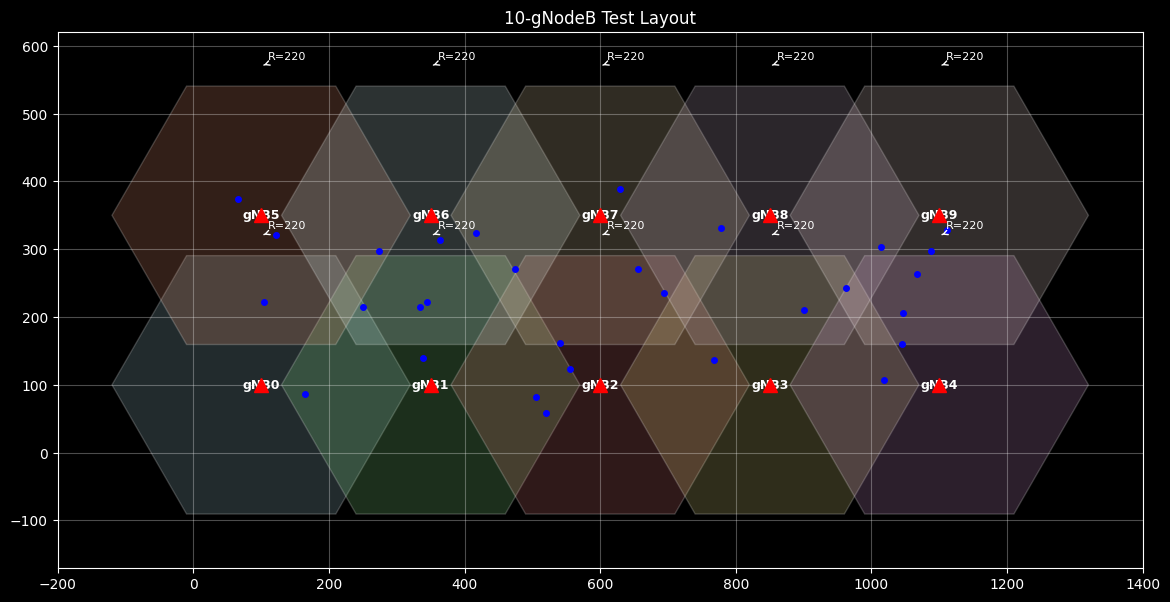

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['lightblue', 'lightgreen', 'lightcoral', 'khaki', 'plum',
          'lightsalmon', 'lightcyan', 'wheat', 'thistle', 'mistyrose']

# Track global bounds manually
all_x = []
all_y = []

for i, gnb in enumerate(gnb_list):
    gnb.visualize_coverage(
        ax=ax,
        color=colors[i % len(colors)],
        alpha=0.20,
        edge_color='white',
        linewidth=1
    )

    # collect bounds from vertices
    vx = [v[0] for v in gnb.vertices]
    vy = [v[1] for v in gnb.vertices]
    all_x.extend(vx)
    all_y.extend(vy)

    ax.text(
        gnb.x, gnb.y, f'gNB{i}',
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='white'
    )

# plot UEs
for ue_id, ue in env.get_all_ues().items():
    serving = ue["serving_gnb"]
    c = 'red' if serving is None else 'blue'
    ax.plot(ue["x"], ue["y"], 'o', color=c, markersize=4)

# Set ONE global limit at the end
margin = 80
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

ax.set_aspect('equal')
ax.set_title("10-gNodeB Test Layout")
ax.grid(True, alpha=0.3)
plt.show()

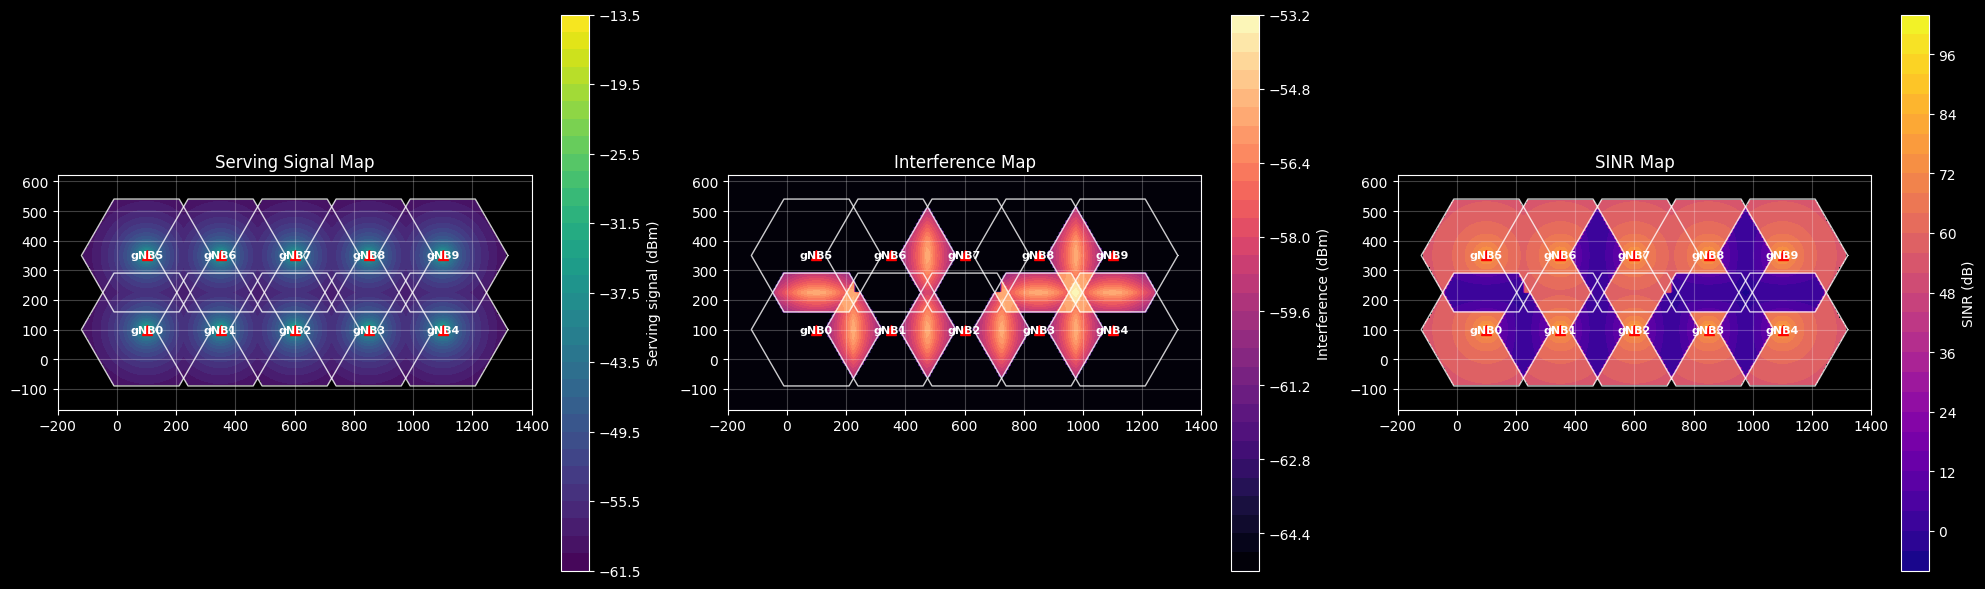

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Radio helpers
# =========================================================

def dbm_to_w(dbm):
    return 10 ** ((dbm - 30) / 10.0)

def w_to_dbm(w):
    w = max(w, 1e-30)
    return 10 * np.log10(w) + 30

def w_to_db(w):
    w = max(w, 1e-30)
    return 10 * np.log10(w)

def noise_power_dbm(rb_bw_hz=180e3, noise_figure_db=7.0):
    # Thermal noise: -174 dBm/Hz
    return -174 + 10 * np.log10(rb_bw_hz) + noise_figure_db

def rx_power_dbm(gnb, x, y):
    """
    Simple free-space/path-loss style received power model.
    Distance in meters, frequency in Hz.
    """
    d_m = max(np.hypot(x - gnb.x, y - gnb.y), 1.0)
    d_km = d_m / 1000.0

    # defaults if attributes do not exist yet
    f_hz = getattr(gnb, "center_frequency_hz", 3.5e9)
    tx_power_dbm = getattr(gnb, "tx_power_dbm", 30.0)

    f_mhz = f_hz / 1e6

    # Urban-macro-ish simple path loss
    # PL(dB) = 32.4 + 20log10(f_MHz) + 20log10(d_km)
    path_loss_db = 32.4 + 20 * np.log10(f_mhz) + 20 * np.log10(d_km)

    return tx_power_dbm - path_loss_db

def same_carrier(g1, g2):
    """
    Carrier reuse rule:
    - if carrier_id exists and equal => same carrier
    - otherwise assume different carriers
    """
    c1 = getattr(g1, "carrier_id", None)
    c2 = getattr(g2, "carrier_id", None)
    return c1 is not None and c2 is not None and c1 == c2

def serving_gnb_index(gnb_list, x, y):
    """
    Best server = strongest received power among covering gNBs.
    If none covers the point, return None.
    """
    best_idx = None
    best_rx = -np.inf

    for i, gnb in enumerate(gnb_list):
        if gnb.is_point_in_coverage(x, y):
            p = rx_power_dbm(gnb, x, y)
            if p > best_rx:
                best_rx = p
                best_idx = i

    return best_idx

def compute_maps(gnb_list, x_grid, y_grid, rb_bw_hz=180e3):
    """
    Returns:
        serving_map_dbm  : strongest serving signal in dBm
        interference_dbm : total interference in dBm
        sinr_db          : SINR in dB
        server_idx_map   : serving gNB index
    """
    noise_dbm_ref = noise_power_dbm(
        rb_bw_hz=rb_bw_hz,
        noise_figure_db=getattr(gnb_list[0], "noise_figure_db", 7.0)
    )
    noise_w = dbm_to_w(noise_dbm_ref)

    X, Y = np.meshgrid(x_grid, y_grid)

    serving_map_dbm = np.full_like(X, np.nan, dtype=float)
    interference_dbm = np.full_like(X, np.nan, dtype=float)
    sinr_db = np.full_like(X, np.nan, dtype=float)
    server_idx_map = np.full_like(X, -1, dtype=int)

    for r in range(X.shape[0]):
        for c in range(X.shape[1]):
            x = X[r, c]
            y = Y[r, c]

            s_idx = serving_gnb_index(gnb_list, x, y)
            if s_idx is None:
                continue

            serving = gnb_list[s_idx]
            s_dbm = rx_power_dbm(serving, x, y)
            s_w = dbm_to_w(s_dbm)

            # Sum interference only from same-carrier gNBs
            interf_w = 0.0
            for j, other in enumerate(gnb_list):
                if j == s_idx:
                    continue
                if not other.is_point_in_coverage(x, y):
                    continue
                if not same_carrier(serving, other):
                    continue

                interf_w += dbm_to_w(rx_power_dbm(other, x, y))

            serving_map_dbm[r, c] = s_dbm
            interference_dbm[r, c] = w_to_dbm(interf_w) if interf_w > 0 else -np.inf
            sinr_db[r, c] = 10 * np.log10(s_w / (noise_w + interf_w))
            server_idx_map[r, c] = s_idx

    return X, Y, serving_map_dbm, interference_dbm, sinr_db, server_idx_map

# =========================================================
# Optional: assign radio params to each gNB if not present
# =========================================================

# Example:
# - different bands by default => no interference
# - to test interference, set neighboring gNBs to same carrier_id

for i, gnb in enumerate(gnb_list):
    if not hasattr(gnb, "carrier_id"):
        gnb.carrier_id = i   # different carrier for each gNB by default
    if not hasattr(gnb, "center_frequency_hz"):
        gnb.center_frequency_hz = 3.5e9
    if not hasattr(gnb, "tx_power_dbm"):
        gnb.tx_power_dbm = 30.0
    if not hasattr(gnb, "noise_figure_db"):
        gnb.noise_figure_db = 7.0

# Uncomment this block to force interference between some overlapping gNBs:
gnb_list[0].carrier_id = 0
gnb_list[1].carrier_id = 0
gnb_list[5].carrier_id = 0
gnb_list[6].carrier_id = 1
gnb_list[7].carrier_id = 1

# =========================================================
# Build global plotting window
# =========================================================

all_x = []
all_y = []
for gnb in gnb_list:
    all_x.extend([v[0] for v in gnb.vertices])
    all_y.extend([v[1] for v in gnb.vertices])

margin = 80
x_min, x_max = min(all_x) - margin, max(all_x) + margin
y_min, y_max = min(all_y) - margin, max(all_y) + margin

x_grid = np.linspace(x_min, x_max, 220)
y_grid = np.linspace(y_min, y_max, 180)

# =========================================================
# Compute maps
# =========================================================

X, Y, serving_map_dbm, interference_dbm, sinr_db, server_idx_map = compute_maps(
    gnb_list, x_grid, y_grid, rb_bw_hz=180e3
)

# Replace -inf interference by a floor for display
interference_plot = interference_dbm.copy()
finite_mask = np.isfinite(interference_plot)
if np.any(finite_mask):
    floor_val = np.nanmin(interference_plot[finite_mask]) - 5
else:
    floor_val = -150
interference_plot[~finite_mask] = floor_val

# =========================================================
# Plot
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Serving signal map
im0 = axes[0].contourf(X, Y, serving_map_dbm, levels=30, cmap="viridis")
fig.colorbar(im0, ax=axes[0], label="Serving signal (dBm)")
axes[0].set_title("Serving Signal Map")

# 2) Interference map
im1 = axes[1].contourf(X, Y, interference_plot, levels=30, cmap="magma")
fig.colorbar(im1, ax=axes[1], label="Interference (dBm)")
axes[1].set_title("Interference Map")

# 3) SINR map
im2 = axes[2].contourf(X, Y, sinr_db, levels=30, cmap="plasma")
fig.colorbar(im2, ax=axes[2], label="SINR (dB)")
axes[2].set_title("SINR Map")

# Overlay gNB hexagons + centers
for ax in axes:
    for i, gnb in enumerate(gnb_list):
        vx = [v[0] for v in gnb.vertices] + [gnb.vertices[0][0]]
        vy = [v[1] for v in gnb.vertices] + [gnb.vertices[0][1]]
        ax.plot(vx, vy, color="white", linewidth=1.0, alpha=0.8)
        ax.plot(gnb.x, gnb.y, '^', color='red', markersize=7)
        ax.text(gnb.x, gnb.y, f"gNB{i}", color="white", fontsize=8,
                ha="center", va="center", fontweight="bold")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from numpy.random import default_rng

from anothermultiwrapper import MultiGNBWrapper
from node_b import NodeB

from slice_l1 import SliceL1eMBB
from slice_ran import SliceRANeMBB
from channel_models import SINRSelectiveFading, MCSCodeset
from schedulers import ProportionalFair
from itertools import count

# -------------------------------------------------
# Basic setup
# -------------------------------------------------
rng = default_rng(42)
slots_per_step = 50
n_prbs = 100

snr_gen = SINRSelectiveFading(rng, 'macro_cell_urban_2GHz', n_prbs=n_prbs)
mcs = MCSCodeset()
scheduler = ProportionalFair(mcs)
user_counter = count()

# Dummy slice config (minimal)
CBR = {'lambda': 2.0/60.0, 't_mean': 30.0, 'bit_rate': 500000}
VBR = {'lambda': 5.0/60.0, 't_mean': 30.0, 'p_size': 1000, 'b_size': 500, 'b_rate': 1}
SLA = {'cbr_th': 10e6, 'cbr_prb': 20, 'cbr_queue': 10e4,
       'vbr_th': 15e6, 'vbr_prb': 30, 'vbr_queue': 15e4}

state_vars = ['cbr_traffic','cbr_th','cbr_prb','cbr_queue','cbr_snr',
              'vbr_traffic','vbr_th','vbr_prb','vbr_queue','vbr_snr']

norm = {k:1.0 for k in state_vars}

# -------------------------------------------------
# Create gNBs
# -------------------------------------------------
def create_gnb(gnb_id, x, y):
    ran = SliceRANeMBB(rng, user_counter, gnb_id, SLA, CBR, VBR, state_vars, norm, slots_per_step)
    l1 = SliceL1eMBB(rng, snr_gen, 50, [ran], scheduler)

    return NodeB(
        id=gnb_id,
        x=x,
        y=y,
        slices_l1=[l1],
        slots_per_step=slots_per_step,
        n_prbs=n_prbs,
        coverage_radius=300,
        carrier_id=gnb_id  # start with different carriers
    )

gnb1 = create_gnb(0, 100, 100)
gnb2 = create_gnb(1, 320, 150)  # overlapping

gnb_list = [gnb1, gnb2]

# -------------------------------------------------
# Create environment
# -------------------------------------------------
env = MultiGNBWrapper(gnb_list, verbose=False)

obs, info = env.reset()

# -------------------------------------------------
# Add UE in overlap region
# -------------------------------------------------
ue_id = env.add_ue(x=220, y=140, vx=0, vy=0)

print("\n==============================")
print("UE POSITION (Overlap zone)")
print("==============================")
print(env.get_ue(ue_id))

# -------------------------------------------------
# CASE 1: DIFFERENT CARRIERS
# -------------------------------------------------
gnb1.carrier_id = 0
gnb2.carrier_id = 1

print("\n==============================")
print("CASE 1: DIFFERENT CARRIERS")
print("==============================")

metrics = env.get_ue_radio_metrics(ue_id)
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

# -------------------------------------------------
# CASE 2: SAME CARRIER (INTERFERENCE)
# -------------------------------------------------
gnb1.carrier_id = 0
gnb2.carrier_id = 0

print("\n==============================")
print("CASE 2: SAME CARRIER (INTERFERENCE)")
print("==============================")

metrics = env.get_ue_radio_metrics(ue_id)
for k, v in metrics.items():
    print(f"{k:25s}: {v}")


UE POSITION (Overlap zone)
{'id': 0, 'x': 220.0, 'y': 140.0, 'vx': 0.0, 'vy': 0.0, 'slice_type': 'eMBB', 'serving_gnb': 1, 'ho_pending': False, 'ho_candidate': None, 'ho_counter': 0}

CASE 1: DIFFERENT CARRIERS
ue_id                    : 0
x                        : 220.0
y                        : 140.0
serving_gnb              : 1
serving_power_dbm        : -53.32457462483194
interference_dbm         : -inf
sinr_db                  : 61.12270032413498

CASE 2: SAME CARRIER (INTERFERENCE)
ue_id                    : 0
x                        : 220.0
y                        : 140.0
serving_gnb              : 1
serving_power_dbm        : -53.32457462483194
interference_dbm         : -55.32256071356477
sinr_db                  : 1.9979807760654884
